## 1. Импорт библиотек и загрузка данных

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import silhouette_score, pairwise_distances
from scipy.sparse import hstack, csr_matrix

df = pd.read_csv("steam_dataset.tsv", sep="\t")
print(df.shape)
df.head()

(54740, 10)


,app_id,title,user_review_percent,user_review_count,discount_percent,release_year,price_base,developer,publisher,tags
0,10,Counter-Strike,96,162043,0,2000.0,9.99,Valve,Valve,Action|FPS|Multiplayer|Shooter|Classic|Team-Ba...
1,20,Team Fortress Classic,86,6641,0,1999.0,4.99,Valve,Valve,Action|FPS|Multiplayer|Classic|Hero Shooter|Sh...
2,30,Day of Defeat,88,4318,0,2003.0,4.99,Valve,Valve,FPS|World War II|Multiplayer|Shooter|Action|Wa...
3,40,Deathmatch Classic,82,2339,0,2001.0,4.99,Valve,Valve,Action|FPS|Classic|Multiplayer|Shooter|First-P...
4,50,Half-Life: Opposing Force,95,22850,0,1999.0,4.99,Gearbox Software,Valve,FPS|Action|Classic|Sci-fi|Singleplayer|Shooter...


## 2. Удаление пустых строк, заполнение пропусков

In [17]:
df = df.dropna(subset=["user_review_percent", "price_base", "release_year"])

for col in ["developer", "publisher", "tags"]:
    df[col] = df[col].fillna("Unknown")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 54714 entries, 0 to 54739
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   app_id               54714 non-null  int64  
 1   title                54714 non-null  object 
 2   user_review_percent  54714 non-null  int64  
 3   user_review_count    54714 non-null  int64  
 4   discount_percent     54714 non-null  int64  
 5   release_year         54714 non-null  float64
 6   price_base           54714 non-null  float64
 7   developer            54714 non-null  object 
 8   publisher            54714 non-null  object 
 9   tags                 54714 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 4.6+ MB
None


## 3. Графики

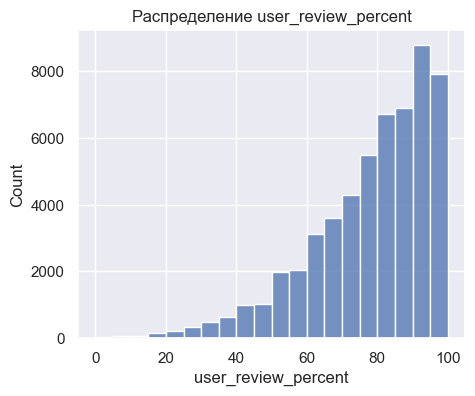

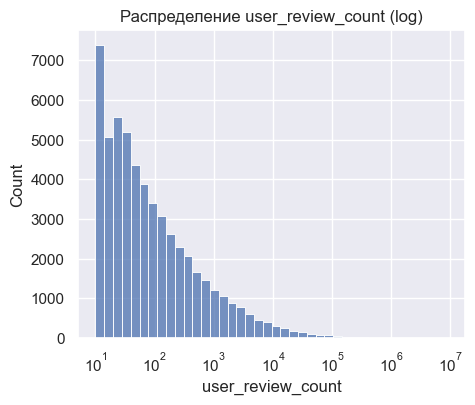

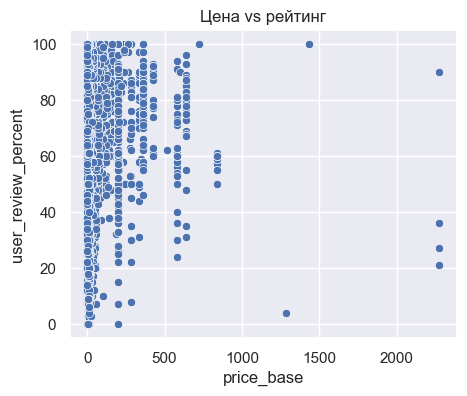

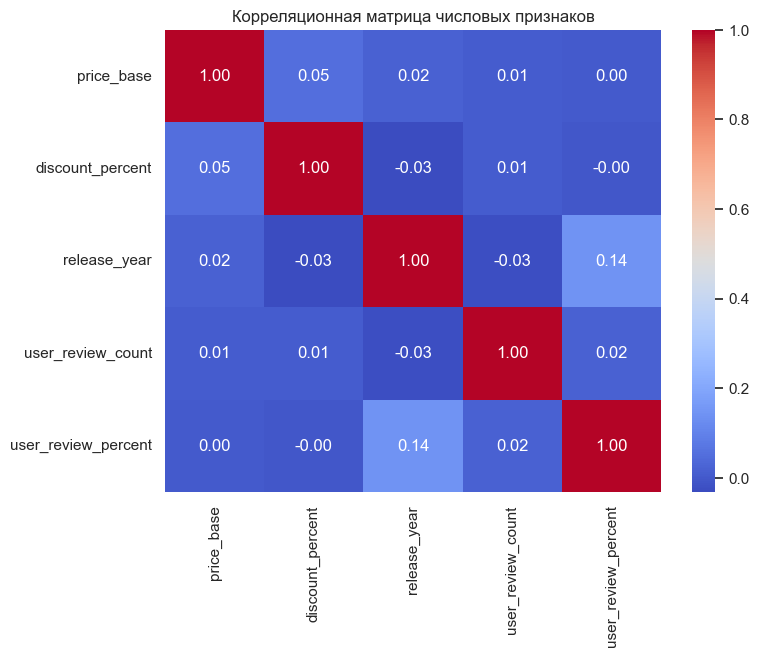

In [18]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(5,4))
sns.histplot(df["user_review_percent"], bins=20)
plt.title("Распределение user_review_percent")
plt.show()

plt.figure(figsize=(5,4))
sns.histplot(df["user_review_count"], bins=40, log_scale=True)
plt.title("Распределение user_review_count (log)")
plt.show()

plt.figure(figsize=(5,4))
sns.scatterplot(x="price_base", y="user_review_percent", data=df)
plt.title("Цена vs рейтинг")
plt.show()

plt.figure(figsize=(8, 6))
corr = df[["price_base", "discount_percent", "release_year",
           "user_review_count", "user_review_percent"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица числовых признаков")
plt.show()

## 4. Работа с категориальными и текстовыми признакми

In [19]:
df["developer_list"] = df["developer"].apply(
    lambda x: [d.strip() for d in str(x).split("|") if d.strip()]
)
df["publisher_list"] = df["publisher"].apply(
    lambda x: [p.strip() for p in str(x).split("|") if p.strip()]
)

mlb_dev = MultiLabelBinarizer()
mlb_pub = MultiLabelBinarizer()

X_dev = mlb_dev.fit_transform(df["developer_list"])
X_pub = mlb_pub.fit_transform(df["publisher_list"])

print("Размерность разработчиков (X_dev):", X_dev.shape)
print("Размерность издателей (X_pub):", X_pub.shape)

def normalize_tags(s):
    tags = [t.strip() for t in str(s).split("|") if t.strip()]
    tags = sorted(set(tags))
    return " | ".join(tags)

df["tags_norm"] = df["tags"].apply(normalize_tags)

vectorizer = CountVectorizer(
    tokenizer=lambda x: x.split(" | "),
    token_pattern=None,
    binary=True
)

X_tags = vectorizer.fit_transform(df["tags_norm"])
print("Размерность тегов (X_tags):", X_tags.shape)

Размерность разработчиков (X_dev): (54714, 36791)
Размерность издателей (X_pub): (54714, 28432)
Размерность тегов (X_tags): (54714, 447)


## 5. Работа с числовыми признаками

In [20]:
num_features = ["price_base", "discount_percent", "release_year",
                "user_review_count", "user_review_percent"]
X_num = csr_matrix(df[num_features].values)

X_num_sparse = csr_matrix(X_num)

print("Размерность числовых признаков (X_num_sparse):", X_num_sparse.shape)

Размерность числовых признаков (X_num_sparse): (54714, 5)


## 6. Объединение данных

In [21]:
X_full = hstack([X_num_sparse, csr_matrix(X_dev), csr_matrix(X_pub), X_tags])
X_full = X_full.astype(np.float32)

scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X_full)

print("Размерность итоговой матрицы:", X_scaled.shape)

Размерность итоговой матрицы: (54714, 65675)


## 7. Baseline

есть скидка -> кластер 1, иначе 0

In [22]:
baseline_clusters = (df["discount_percent"] > 0).astype(int)
print("Baseline кластеров:", np.bincount(baseline_clusters))

silhouette = silhouette_score(X_num, baseline_clusters)
print(f"silhouette score: {silhouette:.3f}")

Baseline кластеров: [46864  7850]
silhouette score: 0.229


## 8. sklearn - KMean

k=2, silhouette=0.314
k=3, silhouette=0.084
k=4, silhouette=-0.078
k=5, silhouette=-0.113
k=6, silhouette=-0.164
k=7, silhouette=-0.164
k=8, silhouette=-0.264


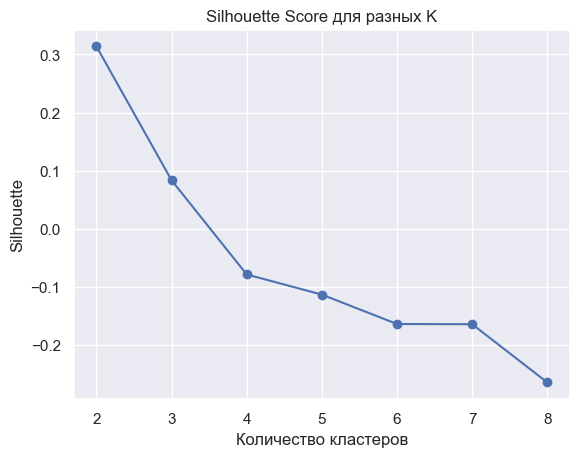

Лучшее k: 2
Silhouette KMeans 0.3138481676578522


C:\Users\vova_\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


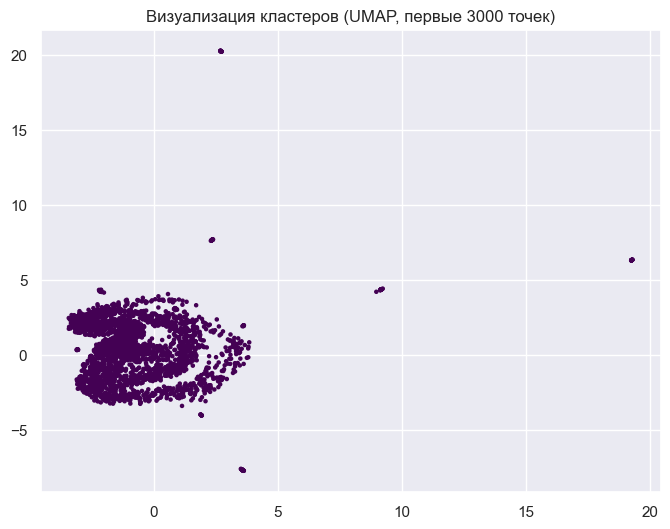

In [31]:
scores = []
K = range(2, 9)

for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, labels)
    scores.append(s)
    print(f"k={k}, silhouette={s:.3f}")

plt.plot(K, scores, marker="o")
plt.title("Silhouette Score для разных K")
plt.xlabel("Количество кластеров")
plt.ylabel("Silhouette")
plt.show()

best_k = K[np.argmax(scores)]
print("Лучшее k:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, kmeans_labels)

print("Silhouette KMeans", sil_kmeans)

N=3000
X_vis = X_scaled[:N]

reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_vis)

plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], c=labels_kmeans[:N], s=5, cmap="viridis")
plt.title("Визуализация кластеров (UMAP, первые 3000 точек)")
plt.show()

## 9. Моя модель

In [47]:
class MyKMeans:
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, n_init=5):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.n_init = n_init

    def fit(self, X):
        X = np.asarray(X)

        best_score = -1
        best_labels = None
        best_centroids = None

        for init_run in range(self.n_init):
            np.random.seed(42 + init_run)
            idx = np.random.choice(len(X))
            centroids = [X[idx]]

            for _ in range(1, self.n_clusters):
                dists = np.min(pairwise_distances(X, np.array(centroids)), axis=1)
                probs = dists ** 2
                probs /= probs.sum()
                new_idx = np.random.choice(len(X), p=probs)
                centroids.append(X[new_idx])

            centroids = np.array(centroids)
            for _ in range(self.max_iter):
                dists = pairwise_distances(X, centroids)
                labels = np.argmin(dists, axis=1)

                new_centroids = []
                for k in range(self.n_clusters):
                    pts = X[labels == k]
                    if len(pts) == 0:
                        new_centroids.append(centroids[k])
                    else:
                        new_centroids.append(pts.mean(axis=0))
                new_centroids = np.array(new_centroids)

                if np.linalg.norm(centroids - new_centroids) < self.tol:
                    break

                centroids = new_centroids
            if len(np.unique(labels)) < 2:
                continue
            score = silhouette_score(X, labels)

            if score > best_score:
                best_score = score
                best_labels = labels.copy()
                best_centroids = centroids.copy()

        self.labels_ = best_labels
        self.centroids = best_centroids
        return self

X_small = X_scaled[:3000].toarray()

best_score = -1
for k in [2,3,4]:
    model = MyKMeans(n_clusters=k)
    model.fit(X_small)
    s = silhouette_score(X_small, model.labels_)
    print(f"MyKMeans k={k}, silhouette={s:.3f}")
    if s > best_score:
        best_score = s
        best_model = model

sil_my = best_score

MyKMeans k=2, silhouette=0.303
MyKMeans k=3, silhouette=0.230
MyKMeans k=4, silhouette=0.227


## 10. Сравнение

In [48]:
print("Silhouette baseline:", silhouette)
print("Silhouette KMeans sklearn:", sil_kmeans)
print("Silhouette MyKMeans:", sil_my)

Silhouette baseline: 0.22913506833865357
Silhouette KMeans sklearn: 0.3138481676578522
Silhouette MyKMeans: 0.30342990159988403


## 11. Вывод

Сравнение моделей показало, что моя модель работает, silhouette моей модели сопоставим с silhouette Sklearn.
Более того, корреляционная матрица показывает слабые линейные связи между числовыми признаками.
Это означает, что данные не образуют чётких линейных зависимостей,
и кластеризация была сложной задачей.